# [LAB 07] 2. 가설검정의 이해
## #01. 준비작업
### 1. 라이브러리 참조

In [1]:
from hossam import load_data
from helpers import my_plot, my_stats
from pandas import melt, DataFrame

# 가설 검정의 가정에 필요한 패키지
from scipy.stats import shapiro, normaltest, bartlett, levene

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.19


### 2. 데이터 불러오기
- 동일한 제품을 판매하고 있는 서로 다른 두 지역의 매장의 100일간의 일별 매출액을 기록한 가상의 데이터
    - 이 데이터를 사용하여 두 매장의 평균 매출액을 비교하고자 함
    - 수집된 데이터가 평균 비교에 적합한지 확인

In [2]:
origin = load_data('two_store')
origin.head()

📚 동일한 제품을 판매하고 있는 서로 다른 두 지역의 매장의 100일간의 일별 매출액을 기록한 가상의 데이터 (출처: 방송통신대학교 통계학개론)


,store1,store2
0,34,63
1,63,85
2,57,75
3,50,48
4,37,58


## #02. 시각화를 통한 데이터 분포 확인 
### 1. 커널밀도 그래프를 위한 데이터 재배치
- 가설검정을 통해 평균을 비교하기 위해서는 정규성을 충족해야 함
    - 정규 분포 확인을 커널밀도 함수 그래프를 통해 전반적인 데이터의 분포를 확인할 수 있음
    - 정규분포를 충족하는 데이터는 시각화의 모양이 좌우 대칭인 상태로 봉긋하게 나타내야 함

In [3]:
df = melt(origin, var_name='store', value_name='sales')
df.head()

,store,sales
0,store1,34
1,store1,63
2,store1,57
3,store1,50
4,store1,37


### 2. 데이터 분포 시각화

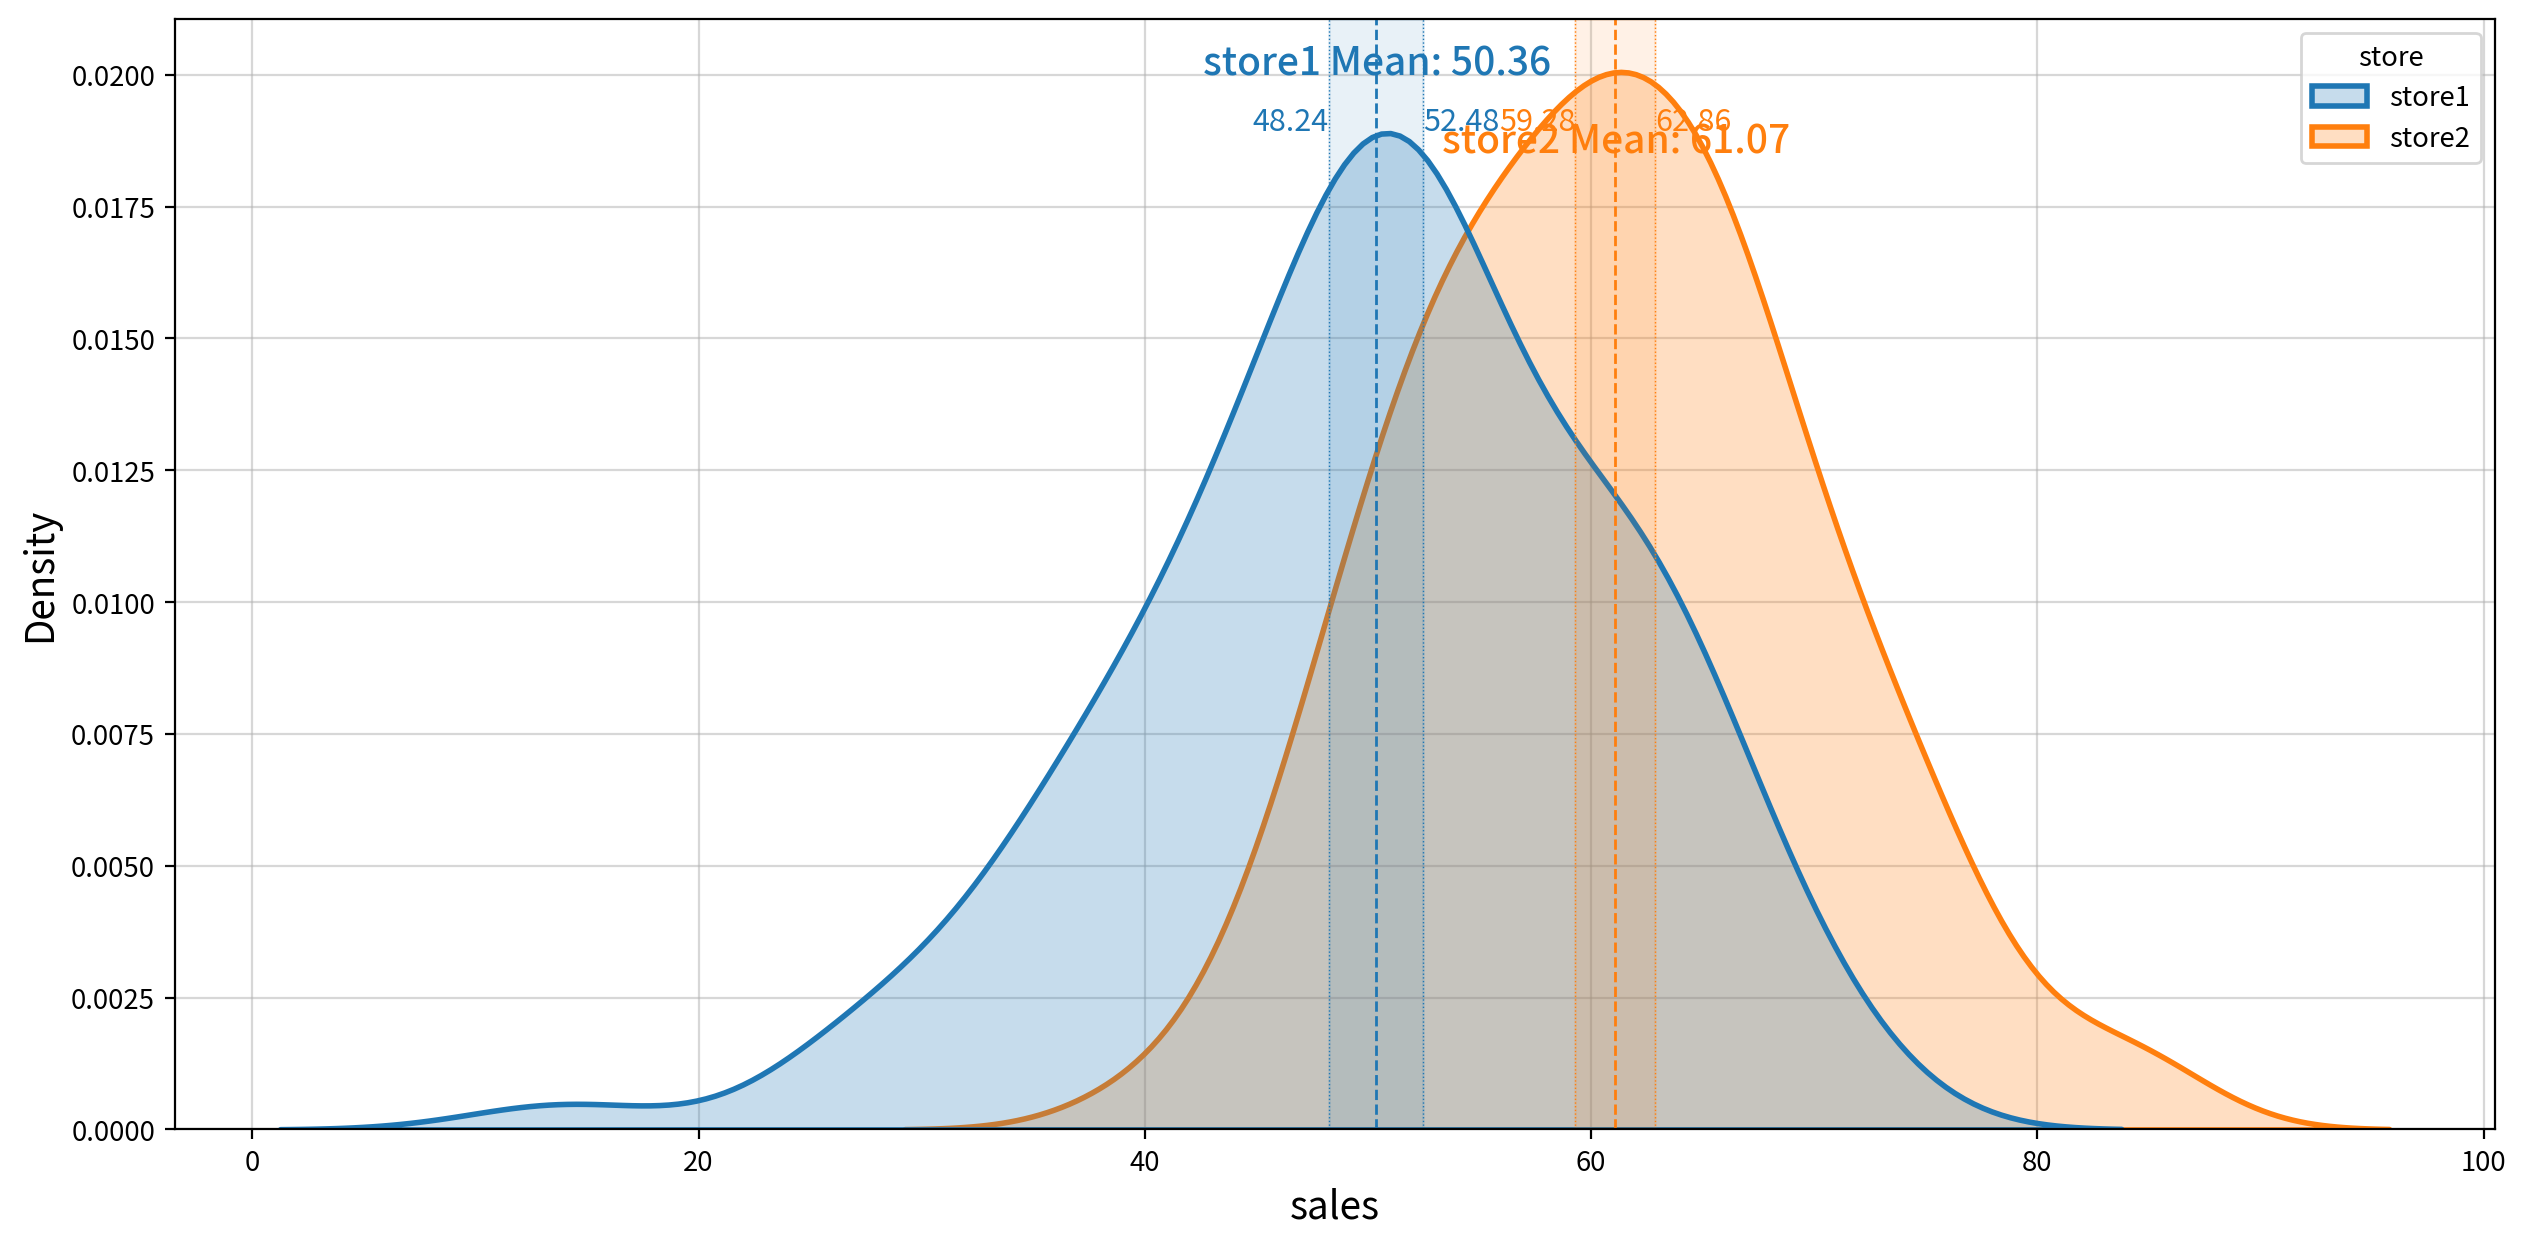

In [4]:
my_plot.kdeplot(df, x='sales', hue='store', meanline=True, clevel=0.95, fill=True)

## #03. 통계량을 통한 데이터 정규성 확인
### 1. Shapiro Wilk 검정 - 스토어1
- 매우 엄격하고 이를 충족하기 위해서는 이상치가 없어야 하며 좌우 대칭도 거의 완전해야 하기 때문에 현실에서 이 기준에 맞는 데이터는 없다고 보는 것이 맞음

In [5]:
nomal_tmpl = "statistic: {0:.3f}, p-value: {1:.3f}, 정규성 충족 여부: {2}"

In [6]:
s, p =shapiro(origin['store1'])
nomal_tmpl.format(s,p,p>=0.05)

'statistic: 0.979, p-value: 0.109, 정규성 충족 여부: True'

### 2. Shapiro Wilk 검정 - 스토어2

In [7]:
s, p =shapiro(origin['store2'])
nomal_tmpl.format(s,p,p>=0.05)

'statistic: 0.991, p-value: 0.731, 정규성 충족 여부: True'

### 3. Normal Test - store1에 대한 검정
- |왜도|<2, |첨도|<7 이면 정규분포에서 크게 벗어나지 않아 정규성을 충족

In [8]:
s,p = normaltest(origin['store1'])
nomal_tmpl.format(s,p,p>=0.05)

'statistic: 5.651, p-value: 0.059, 정규성 충족 여부: True'

### 4. Normal Test - store2에 대한 검정

In [9]:
s,p = normaltest(origin['store2'])
nomal_tmpl.format(s,p,p>=0.05)

'statistic: 1.174, p-value: 0.556, 정규성 충족 여부: True'

## #04. 통계량을 통한 등분산성 확인
### 1. Battlet 검정 
- 모든 변수가 정규성을 충족할 경우 사용
- 정수형이 아닌 실수형 타입을 사용해야 함

In [10]:
var_tmpl = "statistic: {0:.3f}, p-value: {1:.3f}, 등분산성 충족 여부: {2}"

In [11]:
s, p = bartlett(origin['store1'].astype('float'), origin['store2'].astype('float'))
var_tmpl.format(s,p,p>=0.05)

'statistic: 2.844, p-value: 0.092, 등분산성 충족 여부: True'

### 2. Levene 검정
- 비교 대상 데이터 중 하나라도 정규 분포를 따르지 않을 경우 사용
- center 파라미터는 비교할 기준 설정 
    - 레빈 검정의 기본값은 평균을 비교하는 것이지만 실무에서는 중앙값을 비교하는 것이 더 효용성이 높음

In [12]:
# 파라미터 수의 제한이 없음
s, p = levene(origin['store1'], origin['store2'], center='median')
var_tmpl.format(s,p,p>=0.05)

'statistic: 1.360, p-value: 0.245, 등분산성 충족 여부: True'

## #04. 모듈화 기능 확인
### 1. 가설 검정의 가정 일괄 확인

In [13]:
# 정규성을 충족하는 데이터 > Bartlett 검정이 선택됨
# columns 인자를 지정하지 않으몀ㄴ 수치형 컬럼 전체에 대해 검정이 수행됨
my_stats.test_assumptions(origin, columns=['store1', 'store2'])

,test,statistic,p-value,result
field,,,,
store1,normaltest,5.651,0.059,True
store2,normaltest,1.174,0.556,True
Bartlett,equal_var,2.844,0.092,True
